In [1]:
! pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
glioma_grading_clinical_and_mutation_features = fetch_ucirepo(id=759)

# data (as pandas dataframes)
X = glioma_grading_clinical_and_mutation_features.data.features
y = glioma_grading_clinical_and_mutation_features.data.targets

# metadata
print(glioma_grading_clinical_and_mutation_features.metadata)

# variable information
print(glioma_grading_clinical_and_mutation_features.variables)


{'uci_id': 759, 'name': 'Glioma Grading Clinical and Mutation Features', 'repository_url': 'https://archive.ics.uci.edu/dataset/759/glioma+grading+clinical+and+mutation+features+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/759/data.csv', 'abstract': 'Gliomas are the most common primary tumors of the brain. They can be graded as LGG (Lower-Grade Glioma) or GBM (Glioblastoma Multiforme) depending on the histological/imaging criteria. Clinical and molecular/mutation factors are also very crucial for the grading process. Molecular tests are expensive to help accurately diagnose glioma patients.    In this dataset, the most frequently mutated 20 genes and 3 clinical features are considered from TCGA-LGG and TCGA-GBM brain glioma projects.  The prediction task is to determine whether a patient is LGG or GBM with a given clinical and molecular/mutation features. The main objective is to find the optimal subset of mutation genes and clinical features for the glioma grading 

In [3]:
print("Features (X) - Head:")
print(X.head())
print("\nFeatures (X) - Info:")
X.info()
print("\nFeatures (X) - Describe:")
print(X.describe())

print("\nTarget (y) - Head:")
print(y.head())
print("\nTarget (y) - Info:")
y.info()
print("\nTarget (y) - Describe:")
print(y.describe())

Features (X) - Head:
   Gender  Age_at_diagnosis   Race  IDH1  TP53  ATRX  PTEN  EGFR  CIC  MUC16  \
0       0             51.30  white     1     0     0     0     0    0      0   
1       0             38.72  white     1     0     0     0     0    1      0   
2       0             35.17  white     1     1     1     0     0    0      0   
3       1             32.78  white     1     1     1     0     0    0      1   
4       0             31.51  white     1     1     1     0     0    0      0   

   ...  FUBP1  RB1  NOTCH1  BCOR  CSMD3  SMARCA4  GRIN2A  IDH2  FAT4  PDGFRA  
0  ...      1    0       0     0      0        0       0     0     0       0  
1  ...      0    0       0     0      0        0       0     0     0       0  
2  ...      0    0       0     0      0        0       0     0     0       0  
3  ...      0    0       0     0      0        0       0     0     1       0  
4  ...      0    0       0     0      0        0       0     0     0       0  

[5 rows x 23 columns]



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay

# Import classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

In [5]:
# Identify categorical and numerical features
categorical_features = ['Race']
# All other columns except 'Race' are treated as numerical.
# This includes 'Gender' and all gene mutation columns which are binary (0/1).
numerical_features = X.drop(columns=categorical_features).columns.tolist()

# Create preprocessing pipelines for numerical and categorical features
# Numerical features will be scaled
numerical_transformer = StandardScaler()
# Categorical features will be one-hot encoded
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a preprocessor using ColumnTransformer to apply different transformations
# to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split the data into training and testing sets (80% train, 20% test)
# stratify=y ensures that both train and test sets have similar proportions of target classes
X_train, X_test, y_train, y_test = train_test_split(X, y.values.ravel(), test_size=0.2, random_state=42, stratify=y)

print("Data preprocessing and splitting complete.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Data preprocessing and splitting complete.
X_train shape: (671, 23), y_train shape: (671,)
X_test shape: (168, 23), y_test shape: (168,)



==================== Logistic Regression ====================

Confusion Matrix:
[[84 14]
 [10 60]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        98
           1       0.81      0.86      0.83        70

    accuracy                           0.86       168
   macro avg       0.85      0.86      0.85       168
weighted avg       0.86      0.86      0.86       168



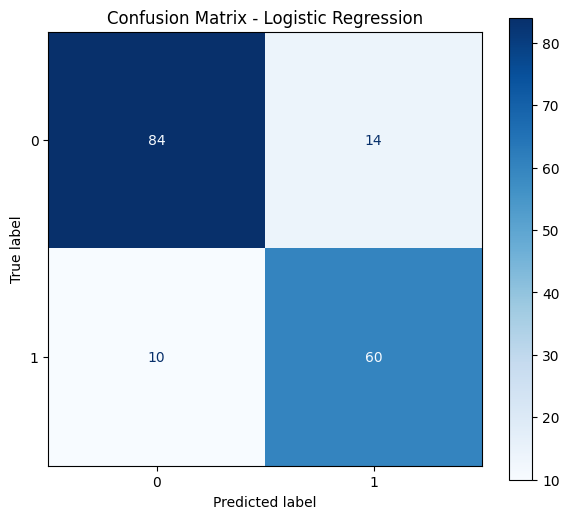

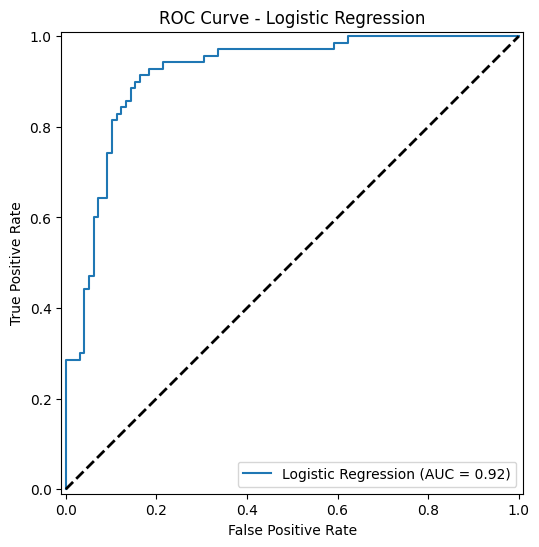


==================== Decision Tree ====================

Confusion Matrix:
[[80 18]
 [21 49]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.80        98
           1       0.73      0.70      0.72        70

    accuracy                           0.77       168
   macro avg       0.76      0.76      0.76       168
weighted avg       0.77      0.77      0.77       168



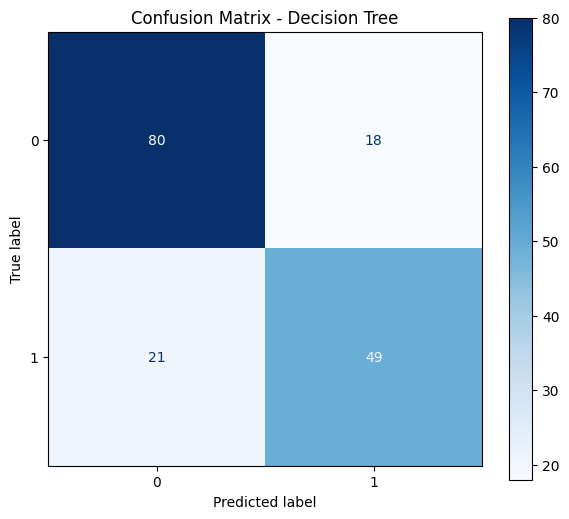

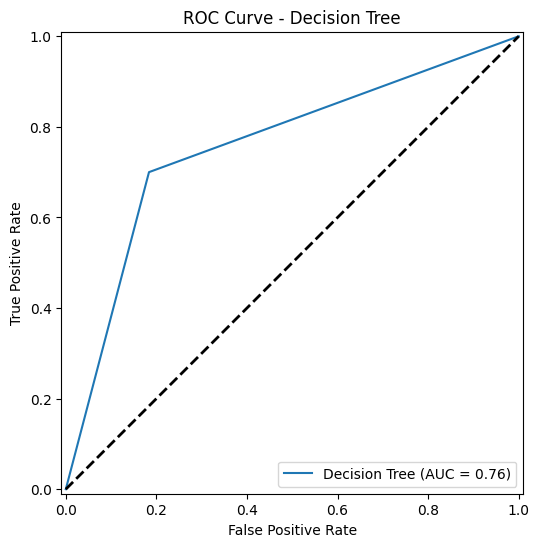


==================== Random Forest ====================

Confusion Matrix:
[[81 17]
 [19 51]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        98
           1       0.75      0.73      0.74        70

    accuracy                           0.79       168
   macro avg       0.78      0.78      0.78       168
weighted avg       0.78      0.79      0.79       168



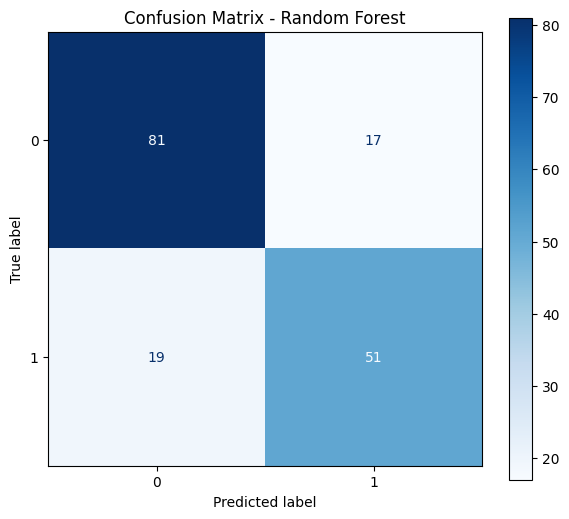

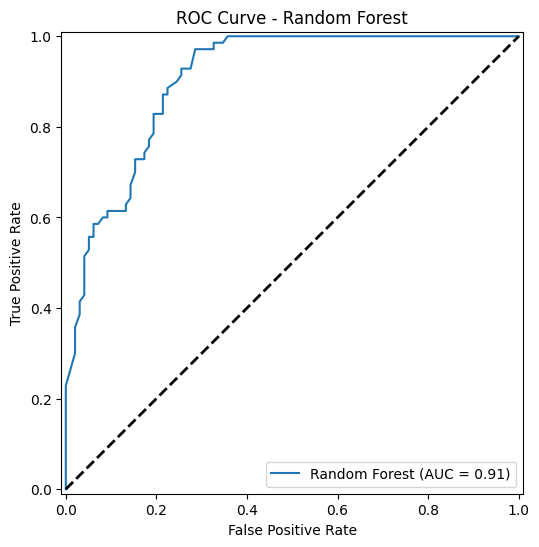


==================== K-Nearest Neighbors ====================

Confusion Matrix:
[[82 16]
 [12 58]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.85        98
           1       0.78      0.83      0.81        70

    accuracy                           0.83       168
   macro avg       0.83      0.83      0.83       168
weighted avg       0.84      0.83      0.83       168



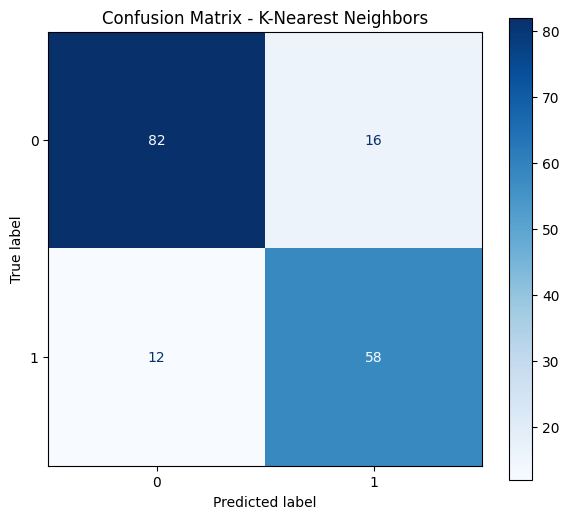

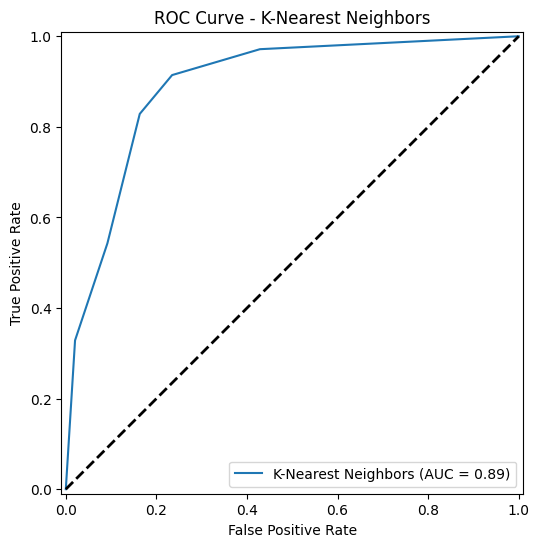


==================== Support Vector Machine ====================

Confusion Matrix:
[[82 16]
 [ 7 63]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88        98
           1       0.80      0.90      0.85        70

    accuracy                           0.86       168
   macro avg       0.86      0.87      0.86       168
weighted avg       0.87      0.86      0.86       168



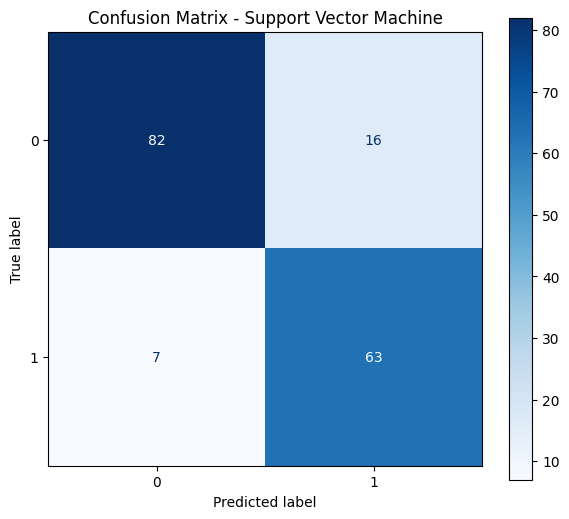

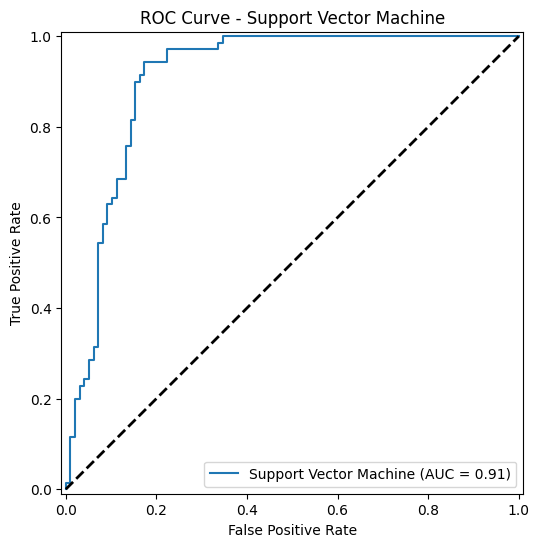


==================== Gaussian Naive Bayes ====================

Confusion Matrix:
[[26 72]
 [ 0 70]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.27      0.42        98
           1       0.49      1.00      0.66        70

    accuracy                           0.57       168
   macro avg       0.75      0.63      0.54       168
weighted avg       0.79      0.57      0.52       168



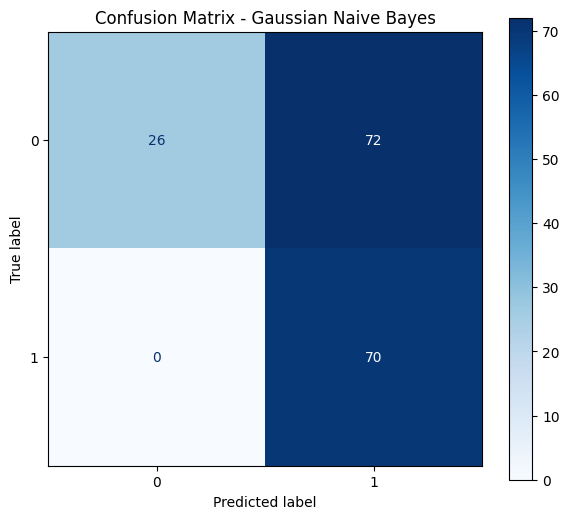

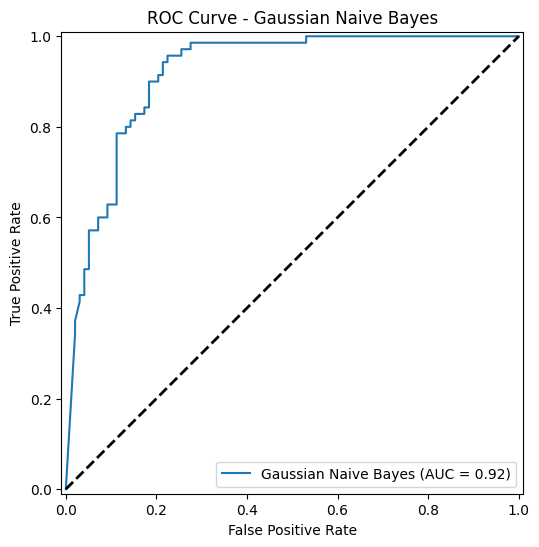


==================== Gradient Boosting ====================

Confusion Matrix:
[[80 18]
 [ 9 61]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        98
           1       0.77      0.87      0.82        70

    accuracy                           0.84       168
   macro avg       0.84      0.84      0.84       168
weighted avg       0.85      0.84      0.84       168



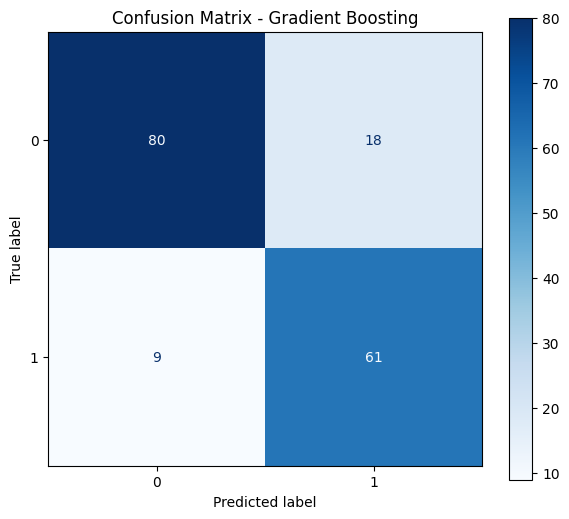

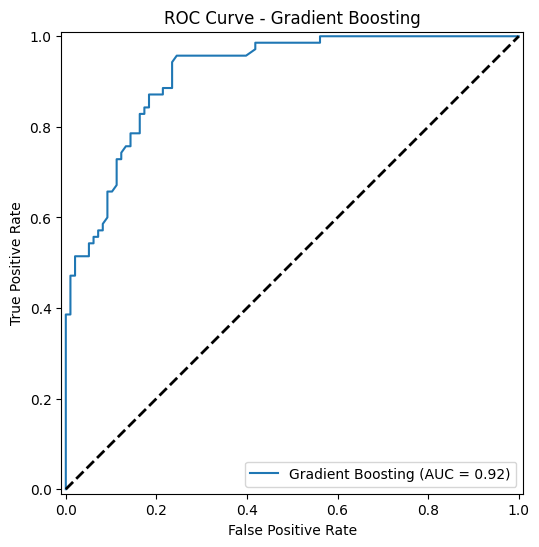


==================== AdaBoost ====================

Confusion Matrix:
[[82 16]
 [ 8 62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.84      0.87        98
           1       0.79      0.89      0.84        70

    accuracy                           0.86       168
   macro avg       0.85      0.86      0.86       168
weighted avg       0.86      0.86      0.86       168



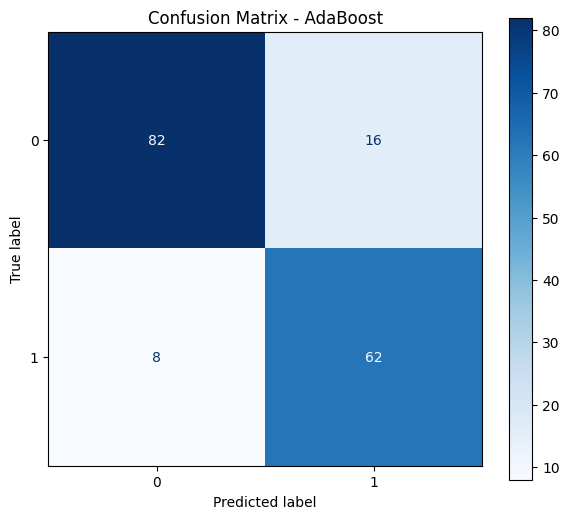

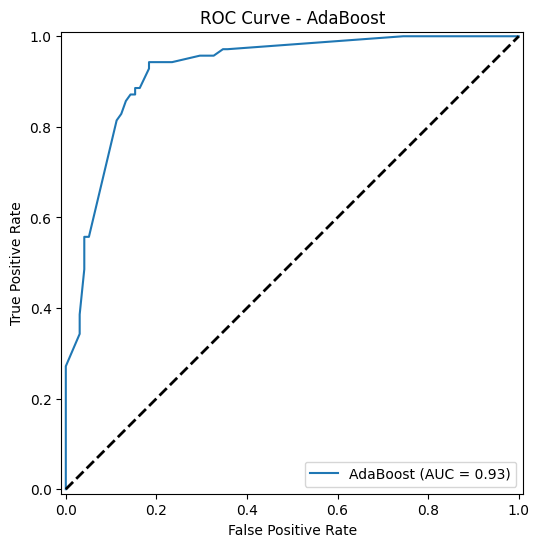


==================== Extra Trees ====================

Confusion Matrix:
[[81 17]
 [22 48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81        98
           1       0.74      0.69      0.71        70

    accuracy                           0.77       168
   macro avg       0.76      0.76      0.76       168
weighted avg       0.77      0.77      0.77       168



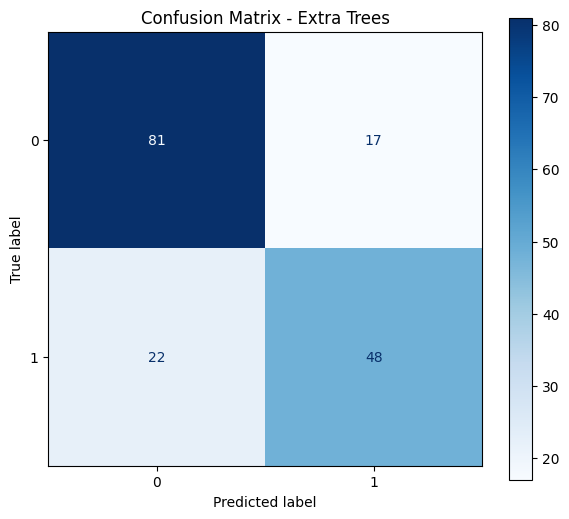

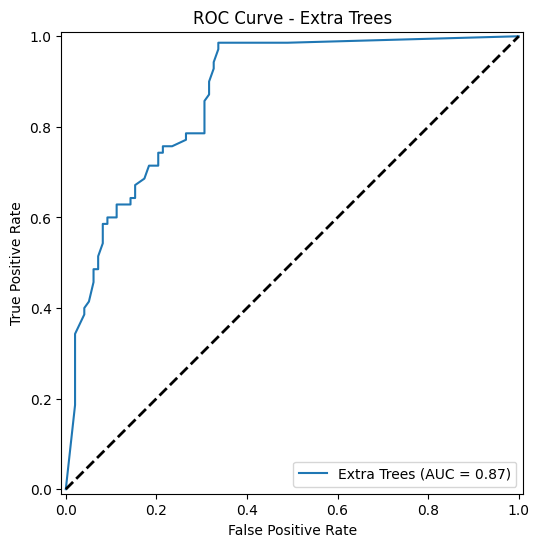


==================== MLP Classifier ====================

Confusion Matrix:
[[80 18]
 [14 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83        98
           1       0.76      0.80      0.78        70

    accuracy                           0.81       168
   macro avg       0.80      0.81      0.81       168
weighted avg       0.81      0.81      0.81       168



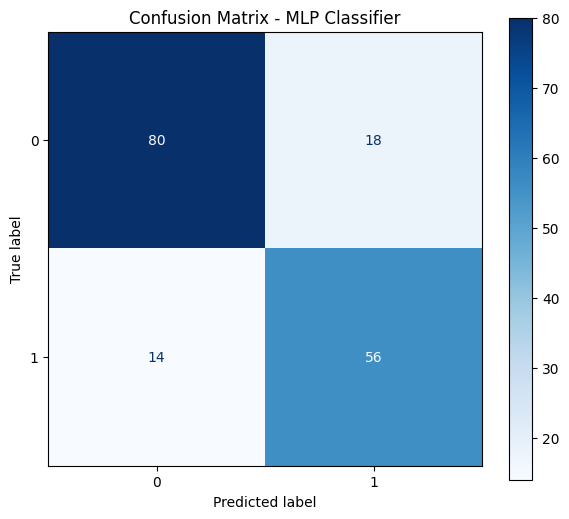

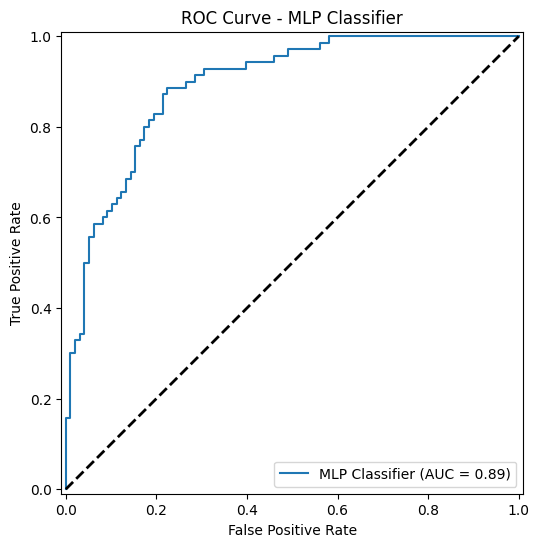

In [6]:
# Define the classification models to be used
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', max_iter=200),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'Gaussian Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42, estimator=DecisionTreeClassifier(max_depth=1)), # Add estimator for AdaBoost if not specified
    'Extra Trees': ExtraTreesClassifier(random_state=42),
    'MLP Classifier': MLPClassifier(random_state=42, max_iter=1000) # Increased max_iter for convergence
}

# Function to evaluate and visualize each model's performance
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test, preprocessor):
    print(f"\n{'='*20} {model_name} {'='*20}")

    # Create a pipeline that first preprocesses the data then trains the model
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', model)])

    # Train the model using the training data
    pipeline.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = pipeline.predict(X_test)

    # Get prediction probabilities for ROC-AUC curve (only for models that support it)
    if hasattr(model, 'predict_proba'):
        y_proba = pipeline.predict_proba(X_test)[:, 1] # Probability of the positive class
    else:
        y_proba = None # Not all models provide probabilities

    # Display Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Display Classification Report (precision, recall, f1-score, support)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Visualize Confusion Matrix
    fig1, ax1 = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, cmap=plt.cm.Blues, ax=ax1)
    ax1.set_title(f'Confusion Matrix - {model_name}')
    plt.show()

    # Visualize ROC-AUC Curve if probabilities are available
    if y_proba is not None:
        fig2, ax2 = plt.subplots(figsize=(7, 6))
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=model_name).plot(ax=ax2)
        ax2.set_title(f'ROC Curve - {model_name}')
        plt.plot([0, 1], [0, 1], 'k--', lw=2) # Plot the diagonal line for reference
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.show()
    else:
        print(f"Note: ROC-AUC curve cannot be plotted for {model_name} as it does not support predict_proba.")

# Loop through each defined model and perform evaluation and visualization
for name, model in models.items():
    evaluate_model(name, model, X_train, X_test, y_train, y_test, preprocessor)


### Convolutional Neural Network (CNN) Model

I will now implement a Convolutional Neural Network (CNN) for this classification task. This will involve preparing the preprocessed data into a suitable format for the CNN, defining a simple CNN architecture, training it, and then evaluating its performance using Confusion Matrix, Classification Report, and ROC-AUC curve.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow Version: {tf.__version__}")

# Apply the preprocessor to the training and testing data
# This transforms numerical features (scaling) and categorical features (one-hot encoding).
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Reshape data for 1D CNN input: (num_samples, num_features, 1)
# Each feature is treated as a single 'channel' in a sequence.
X_train_cnn = X_train_processed.reshape(X_train_processed.shape[0], X_train_processed.shape[1], 1)
X_test_cnn = X_test_processed.reshape(X_test_processed.shape[0], X_test_processed.shape[1], 1)

print(f"X_train_cnn shape: {X_train_cnn.shape}")
print(f"X_test_cnn shape: {X_test_cnn.shape}")

TensorFlow Version: 2.19.0
X_train_cnn shape: (671, 26, 1)
X_test_cnn shape: (168, 26, 1)


### Model Jaringan Saraf Konvolusional (CNN)

Sekarang saya akan mengimplementasikan Jaringan Saraf Konvolusional (CNN) untuk tugas klasifikasi ini. Ini akan melibatkan persiapan data yang telah diproses ke dalam format yang sesuai untuk CNN, mendefinisikan arsitektur CNN sederhana, melatihnya, dan kemudian mengevaluasi kinerjanya menggunakan Matriks Kebingungan, Laporan Klasifikasi, dan kurva ROC-AUC.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow Version: {tf.__version__}")

# Apply the preprocessor to the training and testing data
# This transforms numerical features (scaling) and categorical features (one-hot encoding).
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Reshape data for 1D CNN input: (num_samples, num_features, 1)
# Each feature is treated as a single 'channel' in a sequence.
X_train_cnn = X_train_processed.reshape(X_train_processed.shape[0], X_train_processed.shape[1], 1)
X_test_cnn = X_test_processed.reshape(X_test_processed.shape[0], X_test_processed.shape[1], 1)

print(f"X_train_cnn shape: {X_train_cnn.shape}")
print(f"X_test_cnn shape: {X_test_cnn.shape}")

TensorFlow Version: 2.19.0
X_train_cnn shape: (671, 26, 1)
X_test_cnn shape: (168, 26, 1)


In [ ]:
# Define the CNN model architecture
model_cnn = keras.Sequential([
    # First Convolutional Layer
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    layers.MaxPooling1D(pool_size=2),

    # Second Convolutional Layer
    layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),

    # Flatten the output for the Dense layers
    layers.Flatten(),

    # Dense (Fully Connected) Layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Dropout for regularization to prevent overfitting

    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid') # Sigmoid activation for binary classification output (0 or 1)
])

# Compile the model
# Optimizer: Adam is a good general-purpose optimizer.
# Loss: Binary cross-entropy is standard for binary classification.
# Metrics: Accuracy to monitor training progress.
model_cnn.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# Display the model summary to see the architecture
model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 24, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 10, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,553 (185.75 KB)

 Trainable params: 47,553 (185.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the CNN model
print("Training CNN model...")
# epochs: Number of times the model will iterate over the entire training dataset.
# batch_size: Number of samples per gradient update.
# validation_split: Fraction of the training data to be used as validation data.
# verbose=0: Suppress output during training.
history = model_cnn.fit(X_train_cnn, y_train,
                        epochs=50,
                        batch_size=32,
                        validation_split=0.2,
                        verbose=0)

print("CNN model training complete.")

# Evaluate the model on the test set
loss, accuracy = model_cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Training CNN model...
CNN model training complete.
Test Loss: 0.4553
Test Accuracy: 0.8155


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

Confusion Matrix (CNN):
[[76 22]
 [ 9 61]]


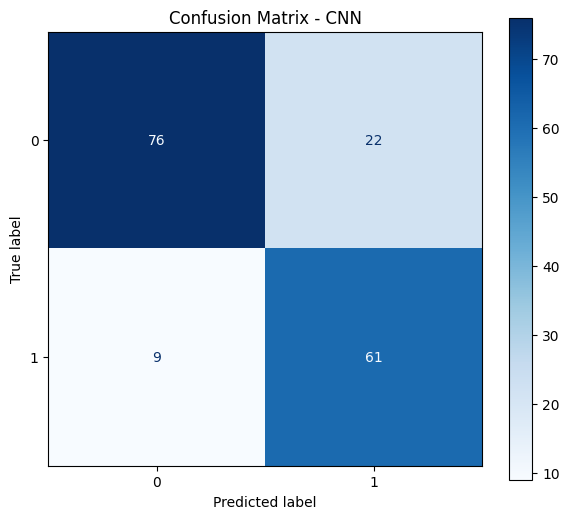


Classification Report (CNN):
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        98
           1       0.73      0.87      0.80        70

    accuracy                           0.82       168
   macro avg       0.81      0.82      0.81       168
weighted avg       0.83      0.82      0.82       168



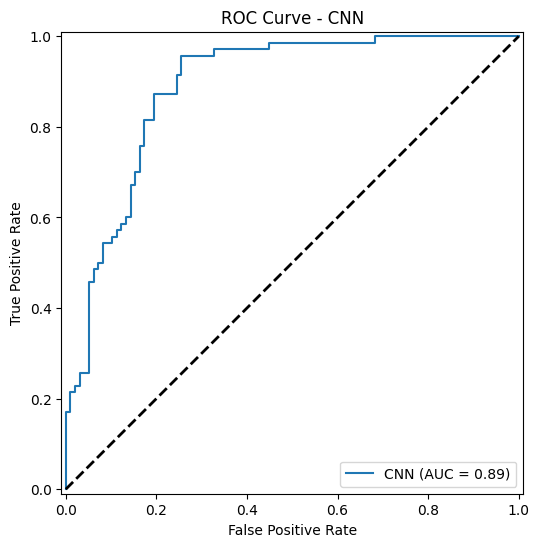

In [ ]:
# Make predictions on the test set
y_pred_cnn_proba = model_cnn.predict(X_test_cnn)
y_pred_cnn = (y_pred_cnn_proba > 0.5).astype(int)

# Display Confusion Matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
print("\nConfusion Matrix (CNN):")
print(cm_cnn)

# Visualize Confusion Matrix
fig_cm_cnn, ax_cm_cnn = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cnn, cmap=plt.cm.Blues, ax=ax_cm_cnn)
ax_cm_cnn.set_title('Confusion Matrix - CNN')
plt.show()

# Display Classification Report
print("\nClassification Report (CNN):")
print(classification_report(y_test, y_pred_cnn))

# Visualize ROC-AUC Curve
fig_roc_cnn, ax_roc_cnn = plt.subplots(figsize=(7, 6))
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_pred_cnn_proba)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)
RocCurveDisplay(fpr=fpr_cnn, tpr=tpr_cnn, roc_auc=roc_auc_cnn, estimator_name='CNN').plot(ax=ax_roc_cnn)
ax_roc_cnn.set_title('ROC Curve - CNN')
plt.plot([0, 1], [0, 1], 'k--', lw=2) # Plot the diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow Version: {tf.__version__}")

# Terapkan preprocessor ke data pelatihan dan pengujian
# Ini mengubah fitur numerik (skala) dan fitur kategorikal (one-hot encoding).
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Bentuk ulang data untuk input CNN 1D: (jumlah_sampel, jumlah_fitur, 1)
# Setiap fitur diperlakukan sebagai 'saluran' tunggal dalam urutan.
X_train_cnn = X_train_processed.reshape(X_train_processed.shape[0], X_train_processed.shape[1], 1)
X_test_cnn = X_test_processed.reshape(X_test_processed.shape[0], X_test_processed.shape[1], 1)

print(f"X_train_cnn shape: {X_train_cnn.shape}")
print(f"X_test_cnn shape: {X_test_cnn.shape}")

TensorFlow Version: 2.19.0
X_train_cnn shape: (671, 26, 1)
X_test_cnn shape: (168, 26, 1)


In [ ]:
# Definisikan arsitektur model CNN
model_cnn = keras.Sequential([
    # Lapisan Konvolusional Pertama
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    layers.MaxPooling1D(pool_size=2),

    # Lapisan Konvolusional Kedua
    layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),

    # Ratakan output untuk lapisan Dense
    layers.Flatten(),

    # Lapisan Dense (Fully Connected)
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Dropout untuk regularisasi untuk mencegah overfitting

    # Lapisan output untuk klasifikasi biner
    layers.Dense(1, activation='sigmoid') # Aktivasi Sigmoid untuk output klasifikasi biner (0 atau 1)
])

# Kompilasi model
# Optimizer: Adam adalah optimizer serbaguna yang baik.
# Loss: Binary cross-entropy adalah standar untuk klasifikasi biner.
# Metrics: Accuracy untuk memantau kemajuan pelatihan.
model_cnn.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# Tampilkan ringkasan model untuk melihat arsitekturnya
model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 24, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 10, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,553 (185.75 KB)

 Trainable params: 47,553 (185.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Latih model CNN
print("Melatih model CNN...")
# epochs: Jumlah berapa kali model akan mengulang seluruh dataset pelatihan.
# batch_size: Jumlah sampel per pembaruan gradien.
# validation_split: Fraksi data pelatihan yang akan digunakan sebagai data validasi.
# verbose=0: Menekan output selama pelatihan.
history = model_cnn.fit(X_train_cnn, y_train,
                        epochs=50,
                        batch_size=32,
                        validation_split=0.2,
                        verbose=0)

print("Pelatihan model CNN selesai.")

# Evaluasi model pada set pengujian
loss, accuracy = model_cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Loss Pengujian: {loss:.4f}")
print(f"Akurasi Pengujian: {accuracy:.4f}")

Melatih model CNN...
Pelatihan model CNN selesai.
Loss Pengujian: 0.4242
Akurasi Pengujian: 0.8274


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Matriks Kebingungan (CNN):
[[82 16]
 [13 57]]


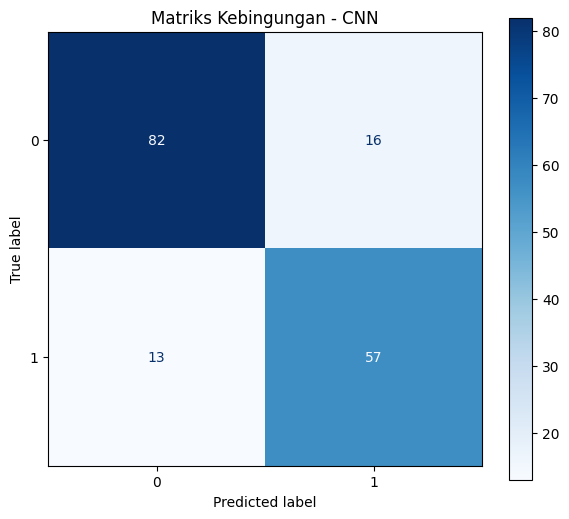


Laporan Klasifikasi (CNN):
              precision    recall  f1-score   support

           0       0.86      0.84      0.85        98
           1       0.78      0.81      0.80        70

    accuracy                           0.83       168
   macro avg       0.82      0.83      0.82       168
weighted avg       0.83      0.83      0.83       168



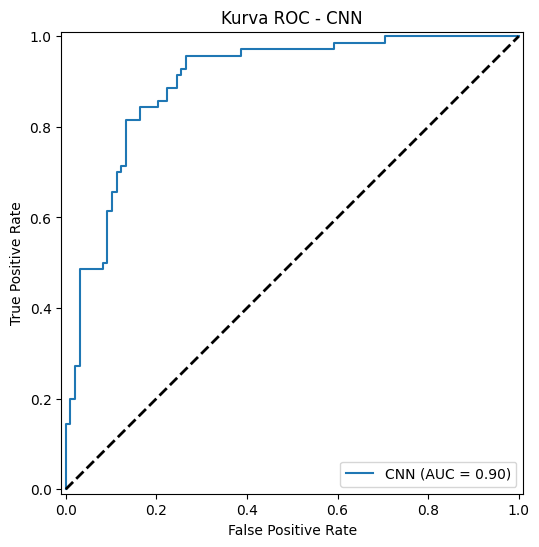

In [ ]:
# Lakukan prediksi pada set pengujian
y_pred_cnn_proba = model_cnn.predict(X_test_cnn)
y_pred_cnn = (y_pred_cnn_proba > 0.5).astype(int)

# Tampilkan Matriks Kebingungan
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
print("\nMatriks Kebingungan (CNN):")
print(cm_cnn)

# Visualisasikan Matriks Kebingungan
fig_cm_cnn, ax_cm_cnn = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cnn, cmap=plt.cm.Blues, ax=ax_cm_cnn)
ax_cm_cnn.set_title('Matriks Kebingungan - CNN')
plt.show()

# Tampilkan Laporan Klasifikasi
print("\nLaporan Klasifikasi (CNN):")
print(classification_report(y_test, y_pred_cnn))

# Visualisasikan Kurva ROC-AUC
fig_roc_cnn, ax_roc_cnn = plt.subplots(figsize=(7, 6))
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_pred_cnn_proba)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)
RocCurveDisplay(fpr=fpr_cnn, tpr=tpr_cnn, roc_auc=roc_auc_cnn, estimator_name='CNN').plot(ax=ax_roc_cnn)
ax_roc_cnn.set_title('Kurva ROC - CNN')
plt.plot([0, 1], [0, 1], 'k--', lw=2) # Plot garis diagonal sebagai referensi
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [ ]:
# Define the CNN model architecture
model_cnn = keras.Sequential([
    # First Convolutional Layer
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    layers.MaxPooling1D(pool_size=2),

    # Second Convolutional Layer
    layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),

    # Flatten the output for the Dense layers
    layers.Flatten(),

    # Dense (Fully Connected) Layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Dropout for regularization to prevent overfitting

    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid') # Sigmoid activation for binary classification output (0 or 1)
])

# Compile the model
# Optimizer: Adam is a good general-purpose optimizer.
# Loss: Binary cross-entropy is standard for binary classification.
# Metrics: Accuracy to monitor training progress.
model_cnn.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# Display the model summary to see the architecture
model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 24, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 10, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,553 (185.75 KB)

 Trainable params: 47,553 (185.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the CNN model
print("Training CNN model...")
# epochs: Number of times the model will iterate over the entire training dataset.
# batch_size: Number of samples per gradient update.
# validation_split: Fraction of the training data to be used as validation data.
# verbose=0: Suppress output during training.
history = model_cnn.fit(X_train_cnn, y_train,
                        epochs=50,
                        batch_size=32,
                        validation_split=0.2,
                        verbose=0)

print("CNN model training complete.")

# Evaluate the model on the test set
loss, accuracy = model_cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Training CNN model...
CNN model training complete.
Test Loss: 0.4215
Test Accuracy: 0.8095


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Confusion Matrix (CNN):
[[78 20]
 [12 58]]


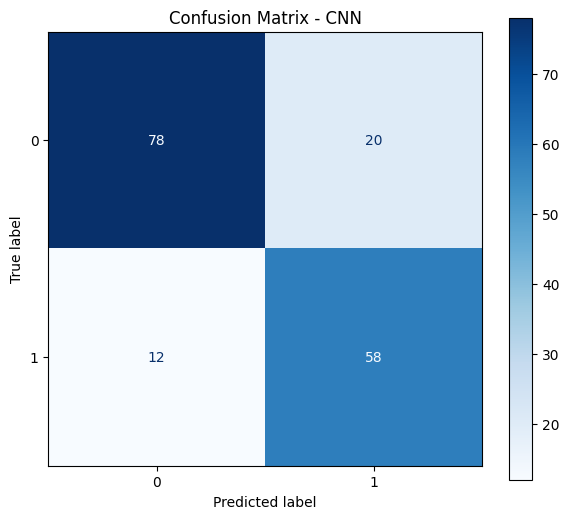


Classification Report (CNN):
              precision    recall  f1-score   support

           0       0.87      0.80      0.83        98
           1       0.74      0.83      0.78        70

    accuracy                           0.81       168
   macro avg       0.81      0.81      0.81       168
weighted avg       0.82      0.81      0.81       168



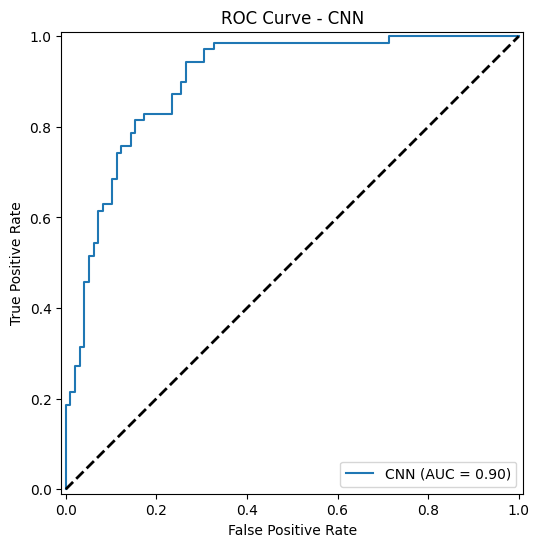

In [ ]:
# Make predictions on the test set
y_pred_cnn_proba = model_cnn.predict(X_test_cnn)
y_pred_cnn = (y_pred_cnn_proba > 0.5).astype(int)

# Display Confusion Matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
print("\nConfusion Matrix (CNN):")
print(cm_cnn)

# Visualize Confusion Matrix
fig_cm_cnn, ax_cm_cnn = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cnn, cmap=plt.cm.Blues, ax=ax_cm_cnn)
ax_cm_cnn.set_title('Confusion Matrix - CNN')
plt.show()

# Display Classification Report
print("\nClassification Report (CNN):")
print(classification_report(y_test, y_pred_cnn))

# Visualize ROC-AUC Curva
fig_roc_cnn, ax_roc_cnn = plt.subplots(figsize=(7, 6))
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_pred_cnn_proba)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)
RocCurveDisplay(fpr=fpr_cnn, tpr=tpr_cnn, roc_auc=roc_auc_cnn, estimator_name='CNN').plot(ax=ax_roc_cnn)
ax_roc_cnn.set_title('ROC Curve - CNN')
plt.plot([0, 1], [0, 1], 'k--', lw=2) # Plot the diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()